# Synthetic Benchmark of JacobiGMRESLCA vs direct LCA solve

This notebook benchmarks the exact `bw2calc.JacobiGMRESLCA.solve_linear_system` method on artificial technosphere matrices, without building Brightway datapackages.

It is designed to:

- vary matrix size from `20_000` to `300_000`
- vary full-matrix density from `0.001%` to `10%`
- compare cold Jacobi-GMRES solves against the regular direct `bw2calc.LCA` solve when feasible
- report solve time, convergence status, residuals, memory estimates, and numerical agreement

Two synthetic matrix families are included:

- `process_lca`: stronger diagonal dominance, meant to resemble process-LCA technospheres
- `input_output`: weaker diagonal dominance at the same density sweep, meant to be more relevant for dense IO systems such as EXIOBASE

Notes:

- Run this notebook with the `bw` conda environment kernel.
- The notebook imports the installed `bw2calc` package from that environment, not the local `src/` checkout.
- When `run_direct = True`, the notebook uses `comparison_sizes` and `comparison_densities` instead of the full grid so you get more direct-solvable cases on a 16 GB machine.
- Large dense cases are automatically skipped on a 16 GB machine using conservative `nnz` and matrix-storage limits.
- The direct baseline uses the regular `bw2calc.LCA.solve_linear_system` path, i.e. the standard one-shot sparse direct solve, not pre-factorization.


In [1]:
import contextlib
import gc
import os
import platform
import sys
import time
import warnings

warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")

from IPython.display import display
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import scipy.sparse as sps
from scipy.sparse import random as sparse_random

import bw2calc
from bw2calc import JacobiGMRESLCA, LCA, __version__ as bw2calc_version
import bw2calc.jacobi_gmres_lca as jglca

PROCESS = psutil.Process(os.getpid())

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"bw2calc version: {bw2calc_version}")
print(f"SciPy version: {scipy.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Direct sparse backend: PYPARDISO={bw2calc.PYPARDISO}, UMFPACK={bw2calc.UMFPACK}")


Python executable: /opt/homebrew/Caskroom/miniforge/base/envs/bw/bin/python
Python version: 3.11.15
Platform: macOS-26.3-arm64-arm-64bit
bw2calc version: 2.4.0
SciPy version: 1.15.2
pandas version: 2.3.3
matplotlib version: 3.10.8
Direct sparse backend: PYPARDISO=False, UMFPACK=True


In [50]:
CONFIG = {
    "sizes": [
        20_000,
        50_000,
        100_000,
        #200_000,
        #300_000
    ],
    "comparison_sizes": [
        #5_000,
        #10_000,
        #15_000,
        20_000,
        30_000,
        40_000,
        100_000
    ],
    "densities": [
        0.0001,
        0.001,
        0.01,
        0.1
    ],
    "comparison_densities": [
        0.0001,
        0.001,
        0.01,
    ],
    "families": {
        "process_lca": {
            "label": "Process-like LCA",
            "dominance_low": 0.05,
            "dominance_high": 0.35,
        },
        "input_output": {
            "label": "Input-output-like",
            "dominance_low": 0.75,
            "dominance_high": 0.98,
        },
    },
    "repeat_count": 1,
    "base_seed": 42,
    "run_direct": True,
    "solver_kwargs": {
        "rtol": 1e-6,
        "atol": 0.0,
        "restart": 50,
        "maxiter": 300,
        "use_guess": False,
    },
    # Conservative limits for a 16 GB laptop. Adjust upward if you want to push harder.
    "iterative_max_nnz": 30_000_000,
    "iterative_max_matrix_gb": 4.0,
    "direct_max_nnz": 4_000_000,
    "direct_max_matrix_gb": 1.5,
}

CONFIG


{'sizes': [20000, 50000, 100000],
 'comparison_sizes': [20000, 30000, 40000, 100000],
 'densities': [0.0001, 0.001, 0.01, 0.1],
 'comparison_densities': [0.0001, 0.001, 0.01],
 'families': {'process_lca': {'label': 'Process-like LCA',
   'dominance_low': 0.05,
   'dominance_high': 0.35},
  'input_output': {'label': 'Input-output-like',
   'dominance_low': 0.75,
   'dominance_high': 0.98}},
 'repeat_count': 1,
 'base_seed': 42,
 'run_direct': True,
 'solver_kwargs': {'rtol': 1e-06,
  'atol': 0.0,
  'restart': 50,
  'maxiter': 300,
  'use_guess': False},
 'iterative_max_nnz': 30000000,
 'iterative_max_matrix_gb': 4.0,
 'direct_max_nnz': 4000000,
 'direct_max_matrix_gb': 1.5}

In [51]:
def format_percent(density):
    return f"{density * 100:.5g}%"


def density_labels(densities):
    return [format_percent(value) for value in densities]


def active_sizes(config):
    if config["run_direct"] and config.get("comparison_sizes"):
        return config["comparison_sizes"]
    return config["sizes"]


def active_densities(config):
    if config["run_direct"] and config.get("comparison_densities"):
        return config["comparison_densities"]
    return config["densities"]


def active_grid_label(config):
    if config["run_direct"]:
        return "direct-vs-iterative comparison grid"
    return "full iterative sweep"


def estimate_target_nnz(n, density):
    return max(n, int(round(density * n * n)))


def estimate_csc_storage_bytes(n, nnz, data_bytes=8, index_bytes=8):
    return nnz * (data_bytes + index_bytes) + (n + 1) * index_bytes


def rss_mb():
    return PROCESS.memory_info().rss / 1024**2


def vector_norm_or_one(vector):
    norm = np.linalg.norm(vector)
    return norm if norm else 1.0


def solution_within_tolerance(iterative_solution, direct_solution, solver_kwargs):
    delta = iterative_solution - direct_solution
    rel_diff = np.linalg.norm(delta) / vector_norm_or_one(direct_solution)
    if rel_diff <= solver_kwargs["rtol"]:
        return True
    if solver_kwargs["atol"] > 0 and np.max(np.abs(delta)) <= solver_kwargs["atol"]:
        return True
    return False


def feasibility_for_case(n, density, config):
    target_nnz = estimate_target_nnz(n, density)
    estimated_matrix_gb = estimate_csc_storage_bytes(n, target_nnz) / 1024**3

    iterative_reason = None
    direct_reason = None
    iterative_feasible = True
    direct_feasible = bool(config["run_direct"])

    if target_nnz > config["iterative_max_nnz"]:
        iterative_feasible = False
        iterative_reason = f"target nnz {target_nnz:,} exceeds iterative_max_nnz"
    elif estimated_matrix_gb > config["iterative_max_matrix_gb"]:
        iterative_feasible = False
        iterative_reason = (
            f"estimated matrix storage {estimated_matrix_gb:.2f} GB exceeds iterative budget"
        )

    if not direct_feasible:
        direct_reason = "direct solver disabled"
    elif target_nnz > config["direct_max_nnz"]:
        direct_feasible = False
        direct_reason = f"target nnz {target_nnz:,} exceeds direct_max_nnz"
    elif estimated_matrix_gb > config["direct_max_matrix_gb"]:
        direct_feasible = False
        direct_reason = f"estimated matrix storage {estimated_matrix_gb:.2f} GB exceeds direct budget"

    return {
        "target_nnz": target_nnz,
        "estimated_matrix_gb": estimated_matrix_gb,
        "iterative_feasible": iterative_feasible,
        "iterative_skip_reason": iterative_reason,
        "direct_feasible": direct_feasible,
        "direct_skip_reason": direct_reason,
    }


def build_case_grid(config):
    rows = []
    sizes = active_sizes(config)
    densities = active_densities(config)
    for family, family_cfg in config["families"].items():
        for n in sizes:
            for density in densities:
                row = {
                    "family": family,
                    "family_label": family_cfg["label"],
                    "n": n,
                    "density_target": density,
                    "density_label": format_percent(density),
                }
                row.update(feasibility_for_case(n, density, config))
                rows.append(row)
    return pd.DataFrame(rows)


def generate_synthetic_technosphere(n, density, family_cfg, seed):
    rng = np.random.default_rng(seed)
    target_total_nnz = estimate_target_nnz(n, density)
    target_offdiag_nnz = max(target_total_nnz - n, 0)
    offdiag_slots = n * (n - 1)
    offdiag_density = 0.0 if offdiag_slots == 0 else min(target_offdiag_nnz / offdiag_slots, 1.0)

    if offdiag_density == 0:
        matrix = sps.eye(n, format="csc", dtype=np.float64)
    else:
        offdiag = sparse_random(
            n,
            n,
            density=offdiag_density,
            format="csr",
            random_state=rng,
            data_rvs=lambda k: rng.random(k) + 1e-12,
        )
        offdiag.setdiag(0.0)
        offdiag.eliminate_zeros()

        row_sums = np.asarray(offdiag.sum(axis=1)).ravel()
        target_strength = rng.uniform(
            family_cfg["dominance_low"],
            family_cfg["dominance_high"],
            size=n,
        )
        scale = np.divide(
            target_strength,
            row_sums,
            out=np.zeros_like(target_strength),
            where=row_sums > 0,
        )
        offdiag = sps.diags(scale) @ offdiag
        matrix = (sps.eye(n, format="csr", dtype=np.float64) - offdiag).tocsc()

    matrix.sum_duplicates()
    matrix.eliminate_zeros()
    matrix.sort_indices()
    return matrix


def one_hot_demand(n, index=0):
    demand = np.zeros(n, dtype=np.float64)
    demand[index] = 1.0
    return demand


def make_jacobi_solver(matrix, demand, solver_kwargs):
    solver = JacobiGMRESLCA.__new__(JacobiGMRESLCA)
    solver.rtol = solver_kwargs["rtol"]
    solver.atol = solver_kwargs["atol"]
    solver.restart = solver_kwargs["restart"]
    solver.maxiter = solver_kwargs["maxiter"]
    solver.use_guess = solver_kwargs["use_guess"]
    solver._matrix_prepared = False
    solver._cached_preconditioner = None
    solver.guess = None
    solver.technosphere_matrix = matrix
    solver.demand_array = demand
    return solver


def make_direct_solver(matrix, demand):
    solver = LCA.__new__(LCA)
    solver.technosphere_matrix = matrix
    solver.demand_array = demand
    return solver


@contextlib.contextmanager
def capture_gmres():
    original_gmres = jglca.gmres
    state = {
        "info": None,
        "callback_calls": 0,
    }

    def wrapped_gmres(*args, **kwargs):
        user_callback = kwargs.pop("callback", None)

        def callback(value):
            state["callback_calls"] += 1
            if user_callback is not None:
                user_callback(value)

        try:
            result = original_gmres(*args, callback=callback, callback_type="pr_norm", **kwargs)
        except TypeError:
            result = original_gmres(*args, callback=callback, **kwargs)

        state["info"] = result[1]
        return result

    jglca.gmres = wrapped_gmres
    try:
        yield state
    finally:
        jglca.gmres = original_gmres


def solve_iterative(matrix, demand, solver_kwargs):
    gc.collect()
    solver = make_jacobi_solver(matrix, demand, solver_kwargs)
    before_rss = rss_mb()

    with capture_gmres() as gmres_state:
        started = time.perf_counter()
        try:
            solution = solver.solve_linear_system()
            error = None
        except Exception as exc:
            solution = None
            error = repr(exc)
        elapsed = time.perf_counter() - started

    after_rss = rss_mb()
    result = {
        "iterative_time_s": elapsed,
        "iterative_rss_before_mb": before_rss,
        "iterative_rss_after_mb": after_rss,
        "iterative_rss_delta_mb": after_rss - before_rss,
        "iterative_gmres_info": gmres_state["info"],
        "iterative_callback_calls": gmres_state["callback_calls"],
        "iterative_exception": error,
    }

    if solution is None:
        result.update(
            {
                "iterative_status": "error",
                "iterative_converged": False,
                "iterative_rel_residual": np.nan,
            }
        )
        return result, None

    residual = matrix @ solution - demand
    gmres_info = gmres_state["info"]
    converged = gmres_info == 0
    result.update(
        {
            "iterative_status": "converged" if converged else f"info={gmres_info}",
            "iterative_converged": converged,
            "iterative_rel_residual": np.linalg.norm(residual) / vector_norm_or_one(demand),
        }
    )
    return result, solution


def solve_direct(matrix, demand):
    gc.collect()
    solver = make_direct_solver(matrix, demand)
    before_rss = rss_mb()
    started = time.perf_counter()

    try:
        solution = solver.solve_linear_system()
        error = None
    except Exception as exc:
        solution = None
        error = repr(exc)

    elapsed = time.perf_counter() - started
    after_rss = rss_mb()
    result = {
        "direct_time_s": elapsed,
        "direct_rss_before_mb": before_rss,
        "direct_rss_after_mb": after_rss,
        "direct_rss_delta_mb": after_rss - before_rss,
        "direct_exception": error,
    }

    if solution is None:
        result.update(
            {
                "direct_status": "error",
                "direct_rel_residual": np.nan,
            }
        )
        return result, None

    residual = matrix @ solution - demand
    result.update(
        {
            "direct_status": "ok",
            "direct_rel_residual": np.linalg.norm(residual) / vector_norm_or_one(demand),
        }
    )
    return result, solution


def benchmark_grid(config):
    cases = build_case_grid(config)
    rows = []
    total_runs = len(cases) * config["repeat_count"]
    run_counter = 0

    for case_index, case in enumerate(cases.itertuples(index=False), start=1):
        family_cfg = config["families"][case.family]
        for repeat in range(config["repeat_count"]):
            run_counter += 1
            seed = config["base_seed"] + case_index * 1000 + repeat
            print(
                f"[{run_counter}/{total_runs}] {case.family_label}: "
                f"n={case.n:,}, density={case.density_label}, repeat={repeat}"
            )

            row = {
                "family": case.family,
                "family_label": case.family_label,
                "n": case.n,
                "density_target": case.density_target,
                "density_label": case.density_label,
                "target_nnz": case.target_nnz,
                "estimated_matrix_gb": case.estimated_matrix_gb,
                "repeat": repeat,
                "seed": seed,
            }

            if not case.iterative_feasible:
                row.update(
                    {
                        "build_time_s": np.nan,
                        "nnz": np.nan,
                        "actual_density": np.nan,
                        "actual_density_pct": np.nan,
                        "matrix_storage_mb": np.nan,
                        "iterative_status": "skipped_budget",
                        "iterative_converged": False,
                        "iterative_skip_reason": case.iterative_skip_reason,
                        "iterative_time_s": np.nan,
                        "iterative_callback_calls": np.nan,
                        "iterative_gmres_info": np.nan,
                        "iterative_rel_residual": np.nan,
                        "iterative_rss_before_mb": np.nan,
                        "iterative_rss_after_mb": np.nan,
                        "iterative_rss_delta_mb": np.nan,
                        "iterative_exception": None,
                        "direct_status": "skipped_budget",
                        "direct_skip_reason": case.direct_skip_reason or "iterative case skipped first",
                        "direct_time_s": np.nan,
                        "direct_rel_residual": np.nan,
                        "direct_rss_before_mb": np.nan,
                        "direct_rss_after_mb": np.nan,
                        "direct_rss_delta_mb": np.nan,
                        "direct_exception": None,
                        "solution_rel_diff": np.nan,
                        "solution_max_abs_diff": np.nan,
                        "solution_within_tolerance": None,
                        "direct_over_iterative_time_ratio": np.nan,
                    }
                )
                rows.append(row)
                continue

            build_started = time.perf_counter()
            matrix = generate_synthetic_technosphere(
                case.n,
                case.density_target,
                family_cfg,
                seed,
            )
            build_time = time.perf_counter() - build_started
            demand = one_hot_demand(case.n)
            actual_density = matrix.nnz / (case.n * case.n)
            matrix_storage_mb = (
                matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
            ) / 1024**2

            row.update(
                {
                    "build_time_s": build_time,
                    "nnz": matrix.nnz,
                    "actual_density": actual_density,
                    "actual_density_pct": actual_density * 100,
                    "matrix_storage_mb": matrix_storage_mb,
                    "iterative_skip_reason": None,
                    "direct_skip_reason": None,
                }
            )

            iterative_result, iterative_solution = solve_iterative(
                matrix,
                demand,
                config["solver_kwargs"],
            )
            row.update(iterative_result)

            if case.direct_feasible:
                direct_result, direct_solution = solve_direct(matrix, demand)
                row.update(direct_result)
            else:
                direct_solution = None
                row.update(
                    {
                        "direct_status": "skipped_budget",
                        "direct_skip_reason": case.direct_skip_reason,
                        "direct_time_s": np.nan,
                        "direct_rel_residual": np.nan,
                        "direct_rss_before_mb": np.nan,
                        "direct_rss_after_mb": np.nan,
                        "direct_rss_delta_mb": np.nan,
                        "direct_exception": None,
                    }
                )

            if iterative_solution is not None and direct_solution is not None:
                delta = iterative_solution - direct_solution
                row["solution_rel_diff"] = (
                    np.linalg.norm(delta)
                    / vector_norm_or_one(direct_solution)
                )
                row["solution_max_abs_diff"] = np.max(np.abs(delta))
                row["solution_within_tolerance"] = solution_within_tolerance(
                    iterative_solution,
                    direct_solution,
                    config["solver_kwargs"],
                )
            else:
                row["solution_rel_diff"] = np.nan
                row["solution_max_abs_diff"] = np.nan
                row["solution_within_tolerance"] = None

            if (
                np.isfinite(row.get("direct_time_s", np.nan))
                and np.isfinite(row.get("iterative_time_s", np.nan))
                and row["iterative_time_s"] > 0
            ):
                row["direct_over_iterative_time_ratio"] = (
                    row["direct_time_s"] / row["iterative_time_s"]
                )
            else:
                row["direct_over_iterative_time_ratio"] = np.nan

            rows.append(row)
            del iterative_solution, direct_solution, matrix, demand
            gc.collect()

    return pd.DataFrame(rows)


def merge_results(existing_results, new_results):
    key_columns = ["family", "n", "density_target", "repeat"]
    if existing_results is None or len(existing_results) == 0:
        return new_results.copy()
    merged = pd.concat([existing_results, new_results], ignore_index=True)
    return merged.drop_duplicates(subset=key_columns, keep="first").reset_index(drop=True)


## Feasibility Preflight

The table below shows which size-density combinations are expected to run under the current budget rules. Dense large cases are intentionally skipped because they are not realistic on a 16 GB laptop once sparse storage and solver working memory are taken into account.


In [52]:
print(f"Active benchmark mode: {active_grid_label(CONFIG)}")
print(f"Sizes: {active_sizes(CONFIG)}")
print(f"Densities: {active_densities(CONFIG)}")

case_grid = build_case_grid(CONFIG)
display(case_grid)

display(
    case_grid.groupby("family_label")[["iterative_feasible", "direct_feasible"]]
    .sum()
    .rename(columns={
        "iterative_feasible": "iterative-runnable cases",
        "direct_feasible": "direct-runnable cases",
    })
)


Active benchmark mode: direct-vs-iterative comparison grid
Sizes: [20000, 30000, 40000, 100000]
Densities: [0.0001, 0.001, 0.01]


,family,family_label,n,density_target,density_label,target_nnz,estimated_matrix_gb,iterative_feasible,iterative_skip_reason,direct_feasible,direct_skip_reason
0,process_lca,Process-like LCA,20000,0.0001,0.01%,40000,0.000745066,True,None,True,None
1,process_lca,Process-like LCA,20000,0.001,0.1%,400000,0.00610948,True,None,True,None
2,process_lca,Process-like LCA,20000,0.01,1%,4000000,0.0597537,True,None,True,None
3,process_lca,Process-like LCA,30000,0.0001,0.01%,90000,0.00156463,True,None,True,None
4,process_lca,Process-like LCA,30000,0.001,0.1%,900000,0.0136346,True,None,True,None
5,process_lca,Process-like LCA,30000,0.01,1%,9000000,0.134334,True,None,False,"target nnz 9,000,000 exceeds direct_max_nnz"
6,process_lca,Process-like LCA,40000,0.0001,0.01%,160000,0.00268222,True,None,True,None
7,process_lca,Process-like LCA,40000,0.001,0.1%,1600000,0.0241399,True,None,True,None
8,process_lca,Process-like LCA,40000,0.01,1%,16000000,0.238717,True,None,False,"target nnz 16,000,000 exceeds direct_max_nnz"
9,process_lca,Process-like LCA,100000,0.0001,0.01%,1000000,0.0156462,True,None,True,None


,iterative-runnable cases,direct-runnable cases
family_label,,
Input-output-like,11,8
Process-like LCA,11,8


In [ ]:
results = benchmark_grid(CONFIG)
results


[1/24] Process-like LCA: n=20,000, density=0.01%, repeat=0
[2/24] Process-like LCA: n=20,000, density=0.1%, repeat=0
[3/24] Process-like LCA: n=20,000, density=1%, repeat=0
[4/24] Process-like LCA: n=30,000, density=0.01%, repeat=0
[5/24] Process-like LCA: n=30,000, density=0.1%, repeat=0
[6/24] Process-like LCA: n=30,000, density=1%, repeat=0
[7/24] Process-like LCA: n=40,000, density=0.01%, repeat=0
[8/24] Process-like LCA: n=40,000, density=0.1%, repeat=0
[9/24] Process-like LCA: n=40,000, density=1%, repeat=0
[10/24] Process-like LCA: n=100,000, density=0.01%, repeat=0


## Optional Iterative-Only Extension

Run this cell after the main benchmark if you want to append extra iterative-only cases, such as `10%` density, without overwriting the existing `results` dataframe.


In [39]:
ITERATIVE_EXTENSION_CONFIG = dict(CONFIG)
ITERATIVE_EXTENSION_CONFIG["run_direct"] = False
ITERATIVE_EXTENSION_CONFIG["sizes"] = active_sizes(CONFIG)
ITERATIVE_EXTENSION_CONFIG["densities"] = [0.1]
ITERATIVE_EXTENSION_CONFIG["comparison_sizes"] = active_sizes(CONFIG)
ITERATIVE_EXTENSION_CONFIG["comparison_densities"] = [0.1]

print("Appending iterative-only extension cases to existing results")
print(f"Sizes: {ITERATIVE_EXTENSION_CONFIG['sizes']}")
print(f"Densities: {ITERATIVE_EXTENSION_CONFIG['densities']}")

extra_case_grid = build_case_grid(ITERATIVE_EXTENSION_CONFIG)
display(extra_case_grid)

extra_results = benchmark_grid(ITERATIVE_EXTENSION_CONFIG)
results = merge_results(results, extra_results)

print(f"Added {len(extra_results)} extension rows. Combined results now contain {len(results)} rows.")


Appending iterative-only extension cases to existing results
Sizes: [20000, 30000, 40000]
Densities: [0.1]


,family,family_label,n,density_target,density_label,target_nnz,estimated_matrix_gb,iterative_feasible,iterative_skip_reason,direct_feasible,direct_skip_reason
0,process_lca,Process-like LCA,20000,0.1,10%,40000000,0.596195,False,"target nnz 40,000,000 exceeds iterative_max_nnz",False,direct solver disabled
1,process_lca,Process-like LCA,30000,0.1,10%,90000000,1.34133,False,"target nnz 90,000,000 exceeds iterative_max_nnz",False,direct solver disabled
2,process_lca,Process-like LCA,40000,0.1,10%,160000000,2.38448,False,"target nnz 160,000,000 exceeds iterative_max_nnz",False,direct solver disabled
3,input_output,Input-output-like,20000,0.1,10%,40000000,0.596195,False,"target nnz 40,000,000 exceeds iterative_max_nnz",False,direct solver disabled
4,input_output,Input-output-like,30000,0.1,10%,90000000,1.34133,False,"target nnz 90,000,000 exceeds iterative_max_nnz",False,direct solver disabled
5,input_output,Input-output-like,40000,0.1,10%,160000000,2.38448,False,"target nnz 160,000,000 exceeds iterative_max_nnz",False,direct solver disabled


[1/6] Process-like LCA: n=20,000, density=10%, repeat=0
[2/6] Process-like LCA: n=30,000, density=10%, repeat=0
[3/6] Process-like LCA: n=40,000, density=10%, repeat=0
[4/6] Input-output-like: n=20,000, density=10%, repeat=0
[5/6] Input-output-like: n=30,000, density=10%, repeat=0
[6/6] Input-output-like: n=40,000, density=10%, repeat=0
Added 6 extension rows. Combined results now contain 24 rows.


In [42]:
report_columns = [
    "family_label",
    "n",
    "density_label",
    "repeat",
    "nnz",
    "actual_density_pct",
    "matrix_storage_mb",
    "build_time_s",
    "iterative_status",
    "iterative_time_s",
    "iterative_callback_calls",
    "iterative_rel_residual",
    "direct_status",
    "direct_time_s",
    "direct_rel_residual",
    "solution_rel_diff",
    "solution_max_abs_diff",
    "solution_within_tolerance",
    "direct_over_iterative_time_ratio",
]

comparison_kwargs = CONFIG["solver_kwargs"]
print(
    "Direct-comparison check: solution_rel_diff <= rtol, or solution_max_abs_diff <= atol, "
    f"with rtol={comparison_kwargs['rtol']} and atol={comparison_kwargs['atol']}"
)

report = results[report_columns].sort_values(["family_label", "n", "actual_density_pct", "repeat"])
display(report)

summary = (
    results.groupby("family_label")
    .agg(
        cases=("family_label", "size"),
        iterative_converged_cases=("iterative_converged", "sum"),
        direct_success_cases=("direct_status", lambda s: (s == "ok").sum()),
        agreement_pass_cases=("solution_within_tolerance", lambda s: (s == True).sum()),
        agreement_fail_cases=("solution_within_tolerance", lambda s: (s == False).sum()),
        median_iterative_time_s=("iterative_time_s", "median"),
        median_direct_time_s=("direct_time_s", "median"),
        median_iterative_callbacks=("iterative_callback_calls", "median"),
        median_solution_rel_diff=("solution_rel_diff", "median"),
    )
    .sort_index()
)

display(summary)

comparison_failures = results[
    (results["direct_status"] == "ok")
    & (results["solution_within_tolerance"] == False)
][[
    "family_label",
    "n",
    "density_label",
    "iterative_status",
    "iterative_rel_residual",
    "direct_rel_residual",
    "solution_rel_diff",
    "solution_max_abs_diff",
]]

if comparison_failures.empty:
    print("All direct-comparison cases passed the configured tolerance check.")
else:
    print("Cases failing the configured tolerance check:")
    display(comparison_failures)


Direct-comparison check: solution_rel_diff <= rtol, or solution_max_abs_diff <= atol, with rtol=1e-06 and atol=0.0


,family_label,n,density_label,repeat,nnz,actual_density_pct,matrix_storage_mb,build_time_s,iterative_status,iterative_time_s,iterative_callback_calls,iterative_rel_residual,direct_status,direct_time_s,direct_rel_residual,solution_rel_diff,solution_max_abs_diff,solution_within_tolerance,direct_over_iterative_time_ratio
9,Input-output-like,20000,0.01%,0,"40,001",0.0100003,0.534073,0.00828812,converged,0.00311204,1,0,ok,0.00607121,0,0,0,True,1.95088
10,Input-output-like,20000,0.1%,0,"399,992",0.099998,4.65384,0.0485523,converged,0.0193649,12,5.06523e-07,ok,25.9844,1.12423e-16,5.41802e-07,1.78289e-08,True,"1,341.83"
11,Input-output-like,20000,1%,0,4.00001e+06,1,45.8527,0.402201,converged,0.0364744,7,8.21627e-07,skipped_budget,NaN,NaN,NaN,NaN,None,NaN
21,Input-output-like,20000,10%,0,NaN,NaN,NaN,NaN,skipped_budget,NaN,NaN,NaN,skipped_budget,NaN,NaN,NaN,NaN,None,NaN
12,Input-output-like,30000,0.01%,0,"89,997",0.00999967,1.14438,0.0100612,converged,0.02039,15,9.5343e-07,ok,0.336776,1.57058e-16,1.45412e-06,3.90689e-07,False,16.5167
13,Input-output-like,30000,0.1%,0,"900,001",0.1,10.4141,0.0755737,converged,0.0218114,11,2.87358e-07,ok,205.058,2.22539e-16,2.98916e-07,8.13316e-09,True,"9,401.39"
14,Input-output-like,30000,1%,0,9.00002e+06,1,103.111,1.03283,converged,0.0844978,7,2.36875e-07,skipped_budget,NaN,NaN,NaN,NaN,None,NaN
22,Input-output-like,30000,10%,0,NaN,NaN,NaN,NaN,skipped_budget,NaN,NaN,NaN,skipped_budget,NaN,NaN,NaN,NaN,None,NaN
15,Input-output-like,40000,0.01%,0,"160,002",0.0100001,1.98367,0.0160264,converged,0.0707435,30,5.98482e-07,ok,6.03784,4.18735e-17,8.59718e-07,8.86531e-08,True,85.3483
16,Input-output-like,40000,0.1%,0,1.59999e+06,0.0999993,18.463,0.147222,converged,0.0295327,10,5.04036e-07,ok,"1,885.9",1.12374e-16,5.15591e-07,1.1842e-08,True,"63,858.3"


,cases,iterative_converged_cases,direct_success_cases,agreement_pass_cases,agreement_fail_cases,median_iterative_time_s,median_direct_time_s,median_iterative_callbacks,median_solution_rel_diff
family_label,,,,,,,,,
Input-output-like,12,9,6,5,1,0.0295327,16.0111,10,5.28696e-07
Process-like LCA,12,9,6,6,0,0.0113441,19.4091,5,1.90593e-07


Cases failing the configured tolerance check:


,family_label,n,density_label,iterative_status,iterative_rel_residual,direct_rel_residual,solution_rel_diff,solution_max_abs_diff
12,Input-output-like,30000,0.01%,converged,9.5343e-07,1.57058e-16,1.45412e-06,3.90689e-07


In [43]:
def observed_sizes(results):
    return sorted(int(value) for value in results["n"].dropna().unique())


def observed_density_labels(results):
    density_map = (
        results[["density_target", "density_label"]]
        .drop_duplicates()
        .sort_values("density_target")
    )
    return density_map["density_label"].tolist()


def metric_pivot(results, family, value_col):
    family_results = results[results["family"] == family].copy()
    ordered_labels = observed_density_labels(results)
    pivot = family_results.pivot_table(
        index="n",
        columns="density_label",
        values=value_col,
        aggfunc="mean",
    )
    return pivot.reindex(index=observed_sizes(results), columns=ordered_labels)


def plot_metric_heatmaps(
    results,
    value_col,
    title,
    cmap="viridis",
    log_scale=False,
    value_format="{:.2g}",
    title_fontsize=14,
    subplot_title_fontsize=12,
    label_fontsize=11,
    tick_fontsize=10,
    annot_fontsize=8,
    cbar_label_fontsize=11,
):
    families = list(CONFIG["families"].keys())
    fig, axes = plt.subplots(1, len(families), figsize=(7 * len(families), 4.8), constrained_layout=True)
    if len(families) == 1:
        axes = [axes]

    mappable = None

    for ax, family in zip(axes, families):
        pivot = metric_pivot(results, family, value_col)
        data = pivot.to_numpy(dtype=float)
        finite_positive = data[np.isfinite(data) & (data > 0)]
        norm = None
        if log_scale and finite_positive.size:
            norm = mcolors.LogNorm(vmin=finite_positive.min(), vmax=finite_positive.max())

        masked = np.ma.masked_invalid(data)
        mappable = ax.imshow(masked, aspect="auto", cmap=cmap, norm=norm)

        ax.set_title(CONFIG["families"][family]["label"], fontsize=subplot_title_fontsize)
        ax.set_xlabel("Target full-matrix density", fontsize=label_fontsize)
        ax.set_ylabel("Matrix dimension", fontsize=label_fontsize)

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(list(pivot.columns), rotation=45, ha="right", fontsize=tick_fontsize)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{int(value):,}" for value in pivot.index], fontsize=tick_fontsize)


        for row_index in range(data.shape[0]):
            for col_index in range(data.shape[1]):
                value = data[row_index, col_index]
                if np.isfinite(value):
                    rgba = mappable.cmap(mappable.norm(value))
                    r, g, b, _ = rgba
                    luminance = 0.299 * r + 0.587 * g + 0.114 * b
                    text_color = "black" if luminance > 0.5 else "white"
        
                    ax.text(
                        col_index,
                        row_index,
                        value_format.format(value),
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color=text_color,
                    )


    if mappable is not None:
        label = title + (" (log scale)" if log_scale else "")
        cbar = fig.colorbar(mappable, ax=axes, shrink=0.88)
        cbar.set_label(label, fontsize=cbar_label_fontsize)
        cbar.ax.tick_params(labelsize=tick_fontsize)
        

    fig.suptitle(title, fontsize=title_fontsize)
    plt.show()

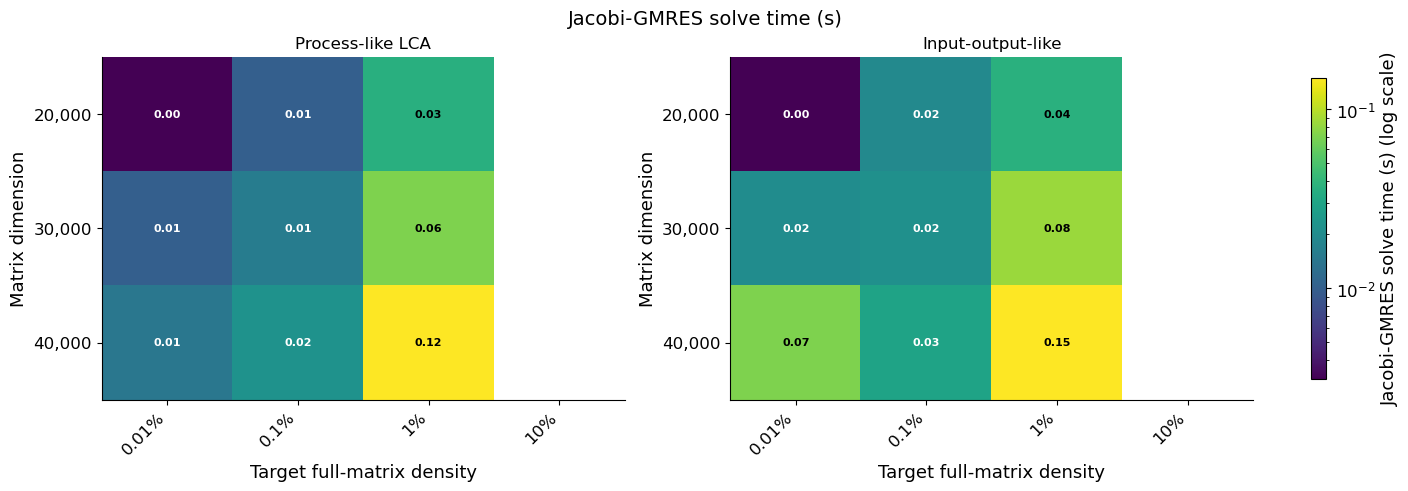

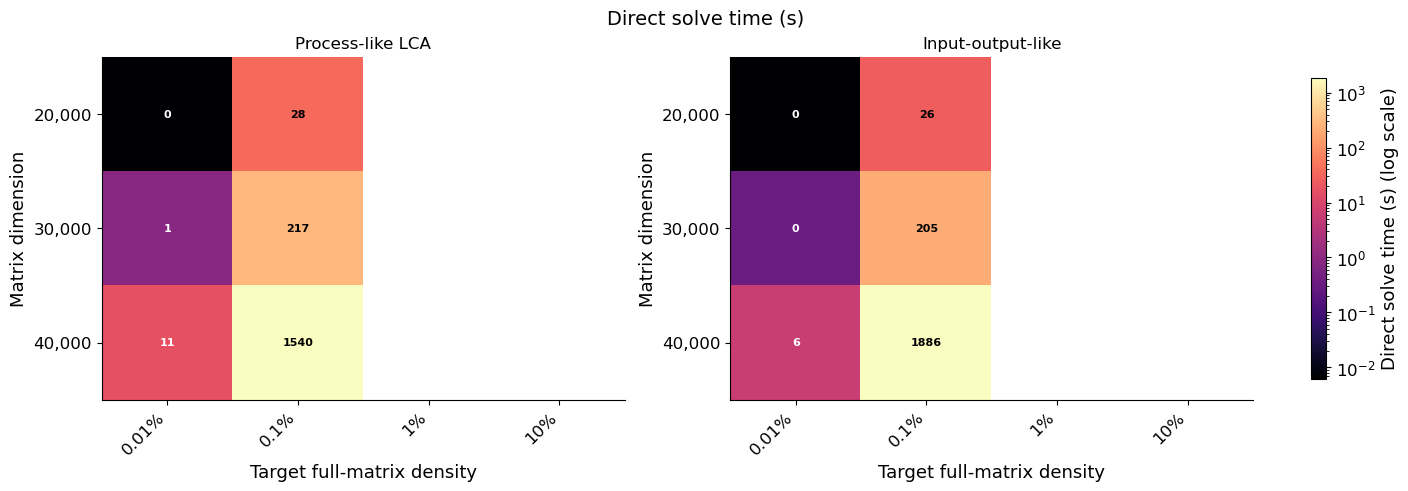

In [44]:

plot_metric_heatmaps(
    results,
    value_col="iterative_time_s",
    title="Jacobi-GMRES solve time (s)",
    cmap="viridis",
    log_scale=True,
    value_format="{:.2f}",
    label_fontsize=13,
    tick_fontsize=12,
    annot_fontsize=10,
    cbar_label_fontsize=13,
)

plot_metric_heatmaps(
    results,
    value_col="direct_time_s",
    title="Direct solve time (s)",
    cmap="magma",
    log_scale=True,
    value_format="{:.0f}",
    label_fontsize=13,
    tick_fontsize=12,
    annot_fontsize=10,
    cbar_label_fontsize=13,
)




## Interpretation Notes

- `direct_over_iterative_time_ratio > 1` means the iterative solve was faster.
- `iterative_status = converged` means the patched GMRES call returned `info == 0`.
- `solution_rel_diff`, `solution_max_abs_diff`, and `solution_within_tolerance` are only available when the direct solve was run successfully for the same matrix.
- `solution_within_tolerance` passes when `solution_rel_diff <= CONFIG["solver_kwargs"]["rtol"]`, or when `solution_max_abs_diff <= CONFIG["solver_kwargs"]["atol"]` if `atol > 0`.
- Skipped cases are not numerical failures; they were excluded by the conservative memory and `nnz` limits in `CONFIG`.

If you want report-ready CSV files, add a final cell such as:

```python
# results.to_csv("synthetic_jacobi_gmres_results.csv", index=False)
# case_grid.to_csv("synthetic_jacobi_gmres_case_grid.csv", index=False)
```
